# 02. 토큰화 및 임베딩

**작성일**: 2026-09-18

**목표**
- 한국어 토큰화 방식(어절/음절/형태소/자모/서브워드)을 실제로 비교하고, 왜 서브워드(BPE)를 베이스라인 토크나이저로 채택하는지 근거를 정리
- 04번 노트북에서 파인튜닝할 사전학습모델(KoBART)의 토크나이저를 그대로 써야 하는 이유를 확인
- gensim Word2Vec으로 임베딩을 직접 학습하고, 학습 과정을 단계별로(형태소분석 → vocab구축 → skip-gram pair 생성 → 학습 → 유사도 확인) 정리

**입력**: `dataset/processed/train.csv` (01번 노트북에서 정제·분할해 저장한 데이터)

이 노트북에서 사용하는 모든 라이브러리·하이퍼파라미터 선택에는 "왜 그것을 썼는지" 이유를 함께 적는다.

In [1]:
# 2026-09-18: 기본 라이브러리 로드 및 01번 노트북 산출물 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트 (01번과 동일)
plt.rcParams['axes.unicode_minus'] = False

train_df = pd.read_csv('../dataset/processed/train.csv')
print(train_df.shape)
train_df.head(3)

(9400, 3)


,Q,A,label
0,외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요.,외롭다고 아무나 좋아하진 않을 거예요.,2
1,지진 걱정돼,한국도 위험해요. 지진시 대피방법을 알아두세요.,0
2,혼자 커피마셔,분위기 있네요.,1


In [2]:
# 2026-09-18: 이후 토큰화 실습에 사용할 예시 문장 3개 선정 (구어체/축약/신조어성 표현 포함)
samples = [
    train_df.iloc[0]['Q'],
    '내일 뭐하지 넘 심심하다ㅋㅋ',
    '오늘 저녁에 뭐 먹을지 고민이에요.',
]
samples

['외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요.', '내일 뭐하지 넘 심심하다ㅋㅋ', '오늘 저녁에 뭐 먹을지 고민이에요.']

## 1. 토큰화 단위 비교 — 어절 / 음절 / 형태소 / 자모

**왜 여러 단위를 비교하는가**: 한국어는 조사·어미가 단어에 결합되는 교착어라서, 토큰화 단위를 어떻게 잡느냐에 따라 같은 의미의 어절이 다른 표층형으로 갈려 vocab이 불필요하게 커지고 데이터가 희소해지는 문제가 생긴다(예: "먹었어요/먹었지만/먹었는데"가 모두 다른 토큰이 됨). 이 문제를 수업 1장(§1-1, §1-2)에서 다룬 방식들로 직접 비교해서, 어떤 단위가 우리 데이터(구어체 챗봇 Q/A)에 적합한지 근거를 만든다.

In [3]:
# 2026-09-18: (1) 어절 단위 - 공백으로만 분리. 구현이 가장 간단하지만 조사/어미가 그대로 붙어있어 vocab이 커짐
def tokenize_eojeol(text: str):
    return text.split()

for s in samples:
    print(s, '->', tokenize_eojeol(s))

외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> ['외로워서', '그런건지', '진짜로', '좋아하는', '건지', '모르겠어요.']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내일', '뭐하지', '넘', '심심하다ㅋㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오늘', '저녁에', '뭐', '먹을지', '고민이에요.']


In [4]:
# 2026-09-18: (2) 음절 단위 - 글자 하나하나로 분리. vocab은 아주 작아지지만(한글 음절 ~2350자) 시퀀스가 길어지고
# 하나의 음절 자체는 의미를 갖지 않는 경우가 많아 표현력이 떨어짐
def tokenize_syllable(text: str):
    return list(text.replace(' ', ''))

for s in samples:
    print(s, '->', tokenize_syllable(s))

외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> ['외', '로', '워', '서', '그', '런', '건', '지', '진', '짜', '로', '좋', '아', '하', '는', '건', '지', '모', '르', '겠', '어', '요', '.']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내', '일', '뭐', '하', '지', '넘', '심', '심', '하', '다', 'ㅋ', 'ㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오', '늘', '저', '녁', '에', '뭐', '먹', '을', '지', '고', '민', '이', '에', '요', '.']


In [5]:
# 2026-09-18: (3) 형태소 단위 - KoNLPy Okt 사용
# 선택 이유: 수업 §1-2에서 다룬 Okt/Kkma 중, Okt는 Kkma보다 처리 속도가 빠르고
# SNS/구어체 텍스트(이모티콘, 축약어, 반복 자모 등)에 더 강건하도록 설계되어 있다.
# ChatbotData는 구어체 대화 데이터이므로 Kkma의 정교한 분석보다는 Okt의 속도/구어체 대응이 더 적합하다고 판단.
from konlpy.tag import Okt

okt = Okt()
for s in samples:
    print(s, '->', okt.morphs(s))

외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> ['외로워', '서', '그런', '건', '지', '진짜', '로', '좋아하는', '건지', '모르겠어요', '.']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['내일', '뭐', '하지', '넘', '심심하다', 'ㅋㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['오늘', '저녁', '에', '뭐', '먹을지', '고민', '이에요', '.']


In [6]:
# 2026-09-18: (4) 자모 단위 - 초성/중성/종성까지 분리
# 오탈자·신조어에 가장 강인하지만(자모가 조금만 달라도 유사하게 처리 가능) 시퀀스 길이가 음절 단위보다도 3배 가까이 길어져
# Transformer의 self-attention 연산량(시퀀스 길이의 제곱에 비례)이 급격히 늘어난다.
# 생성 태스크(Q->A)에서는 시퀀스 길이가 중요한 비용 요소이므로, 자모 단위는 여기서는 '비교' 목적으로만 보고 채택하지 않는다.
from jamo import h2j, j2hcj

def tokenize_jamo(text: str):
    return list(j2hcj(h2j(text.replace(' ', ''))))

for s in samples:
    print(s, '->', tokenize_jamo(s))

외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> ['ㅇ', 'ㅚ', 'ㄹ', 'ㅗ', 'ㅇ', 'ㅝ', 'ㅅ', 'ㅓ', 'ㄱ', 'ㅡ', 'ㄹ', 'ㅓ', 'ㄴ', 'ㄱ', 'ㅓ', 'ㄴ', 'ㅈ', 'ㅣ', 'ㅈ', 'ㅣ', 'ㄴ', 'ㅉ', 'ㅏ', 'ㄹ', 'ㅗ', 'ㅈ', 'ㅗ', 'ㅎ', 'ㅇ', 'ㅏ', 'ㅎ', 'ㅏ', 'ㄴ', 'ㅡ', 'ㄴ', 'ㄱ', 'ㅓ', 'ㄴ', 'ㅈ', 'ㅣ', 'ㅁ', 'ㅗ', 'ㄹ', 'ㅡ', 'ㄱ', 'ㅔ', 'ㅆ', 'ㅇ', 'ㅓ', 'ㅇ', 'ㅛ', '.']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['ㄴ', 'ㅐ', 'ㅇ', 'ㅣ', 'ㄹ', 'ㅁ', 'ㅝ', 'ㅎ', 'ㅏ', 'ㅈ', 'ㅣ', 'ㄴ', 'ㅓ', 'ㅁ', 'ㅅ', 'ㅣ', 'ㅁ', 'ㅅ', 'ㅣ', 'ㅁ', 'ㅎ', 'ㅏ', 'ㄷ', 'ㅏ', 'ㅋ', 'ㅋ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['ㅇ', 'ㅗ', 'ㄴ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅓ', 'ㄴ', 'ㅕ', 'ㄱ', 'ㅇ', 'ㅔ', 'ㅁ', 'ㅝ', 'ㅁ', 'ㅓ', 'ㄱ', 'ㅇ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅣ', 'ㄱ', 'ㅗ', 'ㅁ', 'ㅣ', 'ㄴ', 'ㅇ', 'ㅣ', 'ㅇ', 'ㅔ', 'ㅇ', 'ㅛ', '.']


In [7]:
# 2026-09-18: 네 가지 방식의 평균 토큰 길이 비교 (train_df 전체 Q 대상, 샘플링해서 속도 확보)
sample_qs = train_df['Q'].sample(500, random_state=42).tolist()

len_eojeol = np.mean([len(tokenize_eojeol(s)) for s in sample_qs])
len_syllable = np.mean([len(tokenize_syllable(s)) for s in sample_qs])
len_morph = np.mean([len(okt.morphs(s)) for s in sample_qs])
len_jamo = np.mean([len(tokenize_jamo(s)) for s in sample_qs])

comparison = pd.DataFrame({
    '방식': ['어절', '형태소(Okt)', '음절', '자모'],
    '평균 토큰 수': [len_eojeol, len_morph, len_syllable, len_jamo],
})
comparison

,방식,평균 토큰 수
0,어절,3.530
1,형태소(Okt),5.264
2,음절,10.306
3,자모,24.540


**비교 결과 해석**: 어절 < 형태소 < 음절 < 자모 순으로 평균 토큰 수가 늘어난다(조사/어미가 분리되며 형태소 토큰 수가 어절보다 많아지고, 음절/자모로 갈수록 더 잘게 쪼개짐). 토큰 수가 많을수록 Transformer의 연산 비용(시퀀스 길이의 제곱)과 학습 난이도가 커지므로, 무조건 잘게 쪼갠다고 좋은 것이 아니다. 형태소 단위는 의미 단위를 보존하면서도 vocab 희소성 문제를 줄여주는 절충점이라 뒤의 Word2Vec 임베딩 학습에 채택한다.

## 2. 서브워드(BPE) 토크나이저 직접 학습

**왜 형태소 분석만으로는 부족한가**: Okt 같은 형태소 분석기는 사전(rule) 기반이라 학습 데이터에 없던 신조어·오타·외래어에 약하고, 이런 미등록어는 그대로 unk 처리되거나 분석이 깨진다. 반면 BPE(Byte Pair Encoding) 같은 서브워드 방식은 문자 병합 통계만으로 vocab을 만들기 때문에 이론상 모든 문자열을 표현할 수 있어 OOV(미등록어) 문제가 사실상 사라진다. BERT/GPT/BART/T5 등 우리가 다음 단계에서 쓸 사전학습 Transformer들이 예외 없이 서브워드 토크나이저를 쓰는 이유도 동일하다.

**SentencePiece를 선택한 이유(WordPiece 대비, 수업 §2-2 vs §2-3)**: WordPiece는 공백 기준으로 먼저 단어를 나눈 뒤 그 안에서만 서브워드를 만들지만, SentencePiece는 원문을 공백 포함 raw text 그대로 다루기 때문에 띄어쓰기가 불규칙한 구어체 한국어(예: "안녕하세요" vs "안녕 하세요")에도 안정적이다. 또한 04번 노트북에서 파인튜닝할 KoBART/KE-T5 등 최근 한국어 사전학습 모델 다수가 SentencePiece 기반 토크나이저를 쓰므로, 베이스라인 토크나이저도 SentencePiece로 맞춰 이후 비교가 일관되게 한다.

In [8]:
# 2026-09-18: SentencePiece 학습용 코퍼스 파일 생성 (Q, A를 한 줄씩)
corpus_path = Path('../dataset/processed/corpus_for_bpe.txt')
with open(corpus_path, 'w', encoding='utf-8') as f:
    for q, a in zip(train_df['Q'], train_df['A']):
        f.write(q + '\n')
        f.write(a + '\n')

print('corpus lines:', sum(1 for _ in open(corpus_path, encoding='utf-8')))

corpus lines: 18800


In [9]:
# 2026-09-18: SentencePiece BPE 학습
# vocab_size=8000 선택 근거: 학습 코퍼스가 짧은 대화문 약 1.9만 줄(9400쌍 x 2)로 규모가 크지 않다.
#   - vocab을 너무 크게(3만 이상) 잡으면 rare/저빈도 subword가 많아져 학습이 비효율적이고, 임베딩 파라미터 수만 늘어난다.
#   - vocab을 너무 작게(1천 이하) 잡으면 subword가 지나치게 잘게 쪼개져 시퀀스가 길어지고 의미 단위가 깨진다.
#   - 소규모 대화체 코퍼스에서는 8000~16000 사이가 흔히 쓰이는 범위라 중간값인 8000으로 설정.
# character_coverage=0.9995: 한국어처럼 문자 종류가 많은 언어에서 권장되는 기본값(공식 SentencePiece 문서 권장치)
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input=str(corpus_path),
    model_prefix='../dataset/processed/chatbot_bpe',
    vocab_size=8000,
    model_type='bpe',
    character_coverage=0.9995,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)
print('학습 완료')

학습 완료


In [10]:
# 2026-09-18: 학습된 BPE 토크나이저로 예시 문장 인코딩 (subword 분해 확인)
sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
print('vocab size:', sp.get_piece_size())

for s in samples:
    pieces = sp.encode(s, out_type=str)
    print(s, '->', pieces)

vocab size: 8000
외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> ['▁외로워', '서', '▁그런', '건지', '▁진짜', '로', '▁좋아하는', '▁건지', '▁모르겠어요', '.']
내일 뭐하지 넘 심심하다ㅋㅋ -> ['▁내일', '▁뭐하지', '▁넘', '▁심심', '하다', 'ᄏᄏ']
오늘 저녁에 뭐 먹을지 고민이에요. -> ['▁오늘', '▁저녁에', '▁뭐', '▁먹을', '지', '▁고민', '이에요', '.']


**OOV 대응 확인**: 아래에서 학습 코퍼스에 없을 법한 신조어/외래어 표현을 넣어, 형태소 분석기(Okt)는 어떻게 깨지는지 vs BPE는 어떻게 subword로 분해해 처리하는지 비교한다.

In [11]:
# 2026-09-18: OOV(미등록어) 대응 비교 - 형태소 분석 vs BPE
oov_examples = ['오늘 급여루팡했다', 'ㄹㅇㅋㅋ 완전 갓생살기']

for s in oov_examples:
    print('문장:', s)
    print('  Okt 형태소:', okt.morphs(s))
    print('  BPE subword:', sp.encode(s, out_type=str))
    print()

문장: 오늘 급여루팡했다
  Okt 형태소: ['오늘', '급여', '루팡', '했다']
  BPE subword: ['▁오늘', '▁급', '여', '루', '팡', '했다']

문장: ㄹㅇㅋㅋ 완전 갓생살기
  Okt 형태소: ['ㄹㅇㅋㅋ', '완전', '갓', '생', '살기']
  BPE subword: ['▁', 'ᄅᄋ', 'ᄏᄏ', '▁완전', '▁', '갓', '생', '살', '기']



## 3. 사전학습모델(KoBART) 토크나이저와 비교

**왜 파인튜닝 단계에서는 직접 학습한 BPE를 쓰지 않고 KoBART 자체 토크나이저를 그대로 써야 하는가**: 사전학습 모델의 임베딩 행렬(embedding matrix)은 그 모델의 토크나이저가 만드는 vocab index와 1:1로 대응하도록 학습되어 있다. 토크나이저를 우리가 새로 학습한 것으로 바꾸면 같은 index라도 실제로 가리키는 subword가 달라지므로, 사전학습된 임베딩 가중치가 사실상 무의미해진다. 따라서 04번 노트북에서 KoBART를 파인튜닝할 때는 반드시 `AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')`로 그 모델 전용 토크나이저를 그대로 불러와야 한다. 이번 절에서는 그 토크나이저가 우리 데이터를 어떻게 분해하는지 직접 확인하고, 우리가 학습한 BPE와 비교한다.

In [12]:
# 2026-09-18: KoBART 사전학습 토크나이저 로드 및 비교
# gogamza/kobart-base-v2 선택 이유: 한국어 사전학습 BART 중 Hugging Face에 공개되어 있고 커뮤니티에서 챗봇 응답생성에
# 널리 검증된 모델(SKT KoBART 계열)이라 04번 노트북 파인튜닝 대상으로 채택 예정.
from transformers import AutoTokenizer

kobart_tokenizer = AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')
print('KoBART vocab size:', kobart_tokenizer.vocab_size)

for s in samples:
    print(s)
    print('  우리 BPE   :', sp.encode(s, out_type=str))
    print('  KoBART tok :', kobart_tokenizer.tokenize(s))
    print()

c:\Users\KDS-11\Documents\nlp_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KoBART vocab size: 30000
외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요.
  우리 BPE   : ['▁외로워', '서', '▁그런', '건지', '▁진짜', '로', '▁좋아하는', '▁건지', '▁모르겠어요', '.']
  KoBART tok : ['▁외', '로', '워서', '▁그런', '건', '지', '▁진짜', '로', '▁좋아하는', '▁건', '지', '▁모르겠', '어요.']

내일 뭐하지 넘 심심하다ㅋㅋ
  우리 BPE   : ['▁내일', '▁뭐하지', '▁넘', '▁심심', '하다', 'ᄏᄏ']
  KoBART tok : ['▁내일', '▁뭐', '하지', '▁넘', '▁심', '심', '하다', 'ᄏ', 'ᄏ']

오늘 저녁에 뭐 먹을지 고민이에요.
  우리 BPE   : ['▁오늘', '▁저녁에', '▁뭐', '▁먹을', '지', '▁고민', '이에요', '.']
  KoBART tok : ['▁오늘', '▁저녁', '에', '▁뭐', '▁먹을', '지', '▁고민', '이에', '요.']



**비교 요약**: 우리가 학습한 BPE(vocab 8000)는 ChatbotData 자체 분포에 최적화되어 있어 이 데이터에서는 subword가 더 적게 쪼개질 수 있지만, KoBART 토크나이저(vocab 더 큼, 더 큰 일반 코퍼스로 학습)는 범용성이 높다. 결론적으로:
- **베이스라인(직접구현 Transformer, 03번 노트북)**: 여기서 학습한 SentencePiece BPE(`chatbot_bpe.model`) 사용
- **전이학습 모델(KoBART/KE-T5, 04번 노트북)**: 반드시 해당 모델의 `AutoTokenizer`를 그대로 사용

## 4. Word2Vec 임베딩 학습 (gensim)

**단계별 흐름** (수업 §4, §5에서 다룬 직접구현 skip-gram과 gensim 버전 중, 실제 품질 좋은 임베딩이 필요하므로 학습 원리는 이미 이해했다고 보고 최적화가 잘 된 gensim을 사용):

1. 형태소 분석으로 문장을 토큰 리스트로 변환
2. gensim이 내부적으로 vocab(단어 사전) 구축
3. 각 단어를 중심으로 window 내 주변 단어와의 (중심, 주변) 쌍을 생성
4. Skip-gram + negative sampling으로 각 단어의 벡터를 학습
5. 학습된 벡터로 코사인 유사도 기반 유사 단어 검색

In [13]:
# 2026-09-18: 1단계 - 형태소 분석으로 문장을 토큰 리스트로 변환
# Word2Vec 입력은 BPE subword가 아니라 형태소 단위를 사용한다: subword는 사람이 읽었을 때 의미 단위가 아닌 경우가 많아
# '유사 단어 확인'처럼 해석 가능성이 중요한 임베딩 데모에는 형태소 단위가 더 적합하다(1절의 비교 결론과 동일한 이유).
all_texts = pd.concat([train_df['Q'], train_df['A']]).tolist()
tokenized_corpus = [okt.morphs(t) for t in all_texts]

print('문장 수:', len(tokenized_corpus))
print('예시:', tokenized_corpus[0])

문장 수: 18800
예시: ['외로워', '서', '그런', '건', '지', '진짜', '로', '좋아하는', '건지', '모르겠어요', '.']


In [14]:
# 2026-09-18: 2~4단계 - gensim Word2Vec 학습 (vocab 구축 -> pair 생성 -> skip-gram 학습을 내부적으로 수행)
# sg=1 (skip-gram) 선택 이유: CBOW는 주변 단어로 중심 단어를 예측해 자주 나오는 단어 학습에 유리하지만,
#   챗봇 대화 데이터는 구어체 표현이 다양하고 저빈도 단어가 많다. skip-gram은 중심 단어 하나로 여러 주변 단어를 예측하며
#   저빈도 단어도 여러 번 학습 기회를 얻어 rare word 표현에 더 유리하다(수업 §4-1 근거).
# vector_size=100 선택 이유: 학습 코퍼스가 약 2만 문장으로 크지 않아, 300차원처럼 큰 임베딩은 과적합/희소성 위험이 있다.
#   소규모 코퍼스에서는 100차원 안팎이 일반적으로 권장되는 크기.
# window=5, min_count=2: 관용적인 기본값(너무 작은 min_count는 노이즈성 저빈도 단어까지 학습해 품질을 떨어뜨림).
from gensim.models import Word2Vec

w2v = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
print('학습된 단어 수:', len(w2v.wv))

학습된 단어 수: 6048


In [15]:
# 2026-09-18: 5단계 - 코사인 유사도로 유사 단어 확인
for word in ['사랑', '이별', '고민', '친구']:
    if word in w2v.wv:
        print(f"'{word}' 유사 단어:", w2v.wv.most_similar(word, topn=5))
    else:
        print(f"'{word}' -> vocab에 없음")

'사랑' 유사 단어: [('인정', 0.7852312922477722), ('존중', 0.7716785073280334), ('결정', 0.7422687411308289), ('그대로', 0.7417859435081482), ('존재', 0.7390920519828796)]
'이별' 유사 단어: [('폭풍', 0.8290294408798218), ('재회', 0.8163084983825684), ('만남', 0.795771062374115), ('환승', 0.792979896068573), ('헤어짐', 0.787263810634613)]
'고민' 유사 단어: [('혼전순결', 0.7847675085067749), ('임', 0.757261335849762), ('느낌', 0.7448283433914185), ('너무하는게', 0.7437814474105835), ('가능성', 0.7418054938316345)]
'친구' 유사 단어: [('가족', 0.830510675907135), ('오빠', 0.8222830295562744), ('친', 0.8203892111778259), ('남사', 0.8114374279975891), ('언니', 0.799849808216095)]


In [16]:
# 2026-09-18: 임베딩 학습 결과 저장 (03번 노트북에서 초기화용으로 활용 여부 실험 예정)
out_dir = Path('../dataset/processed')
w2v.save(str(out_dir / 'word2vec.model'))
print('저장 완료:', out_dir / 'word2vec.model')

저장 완료: ..\dataset\processed\word2vec.model


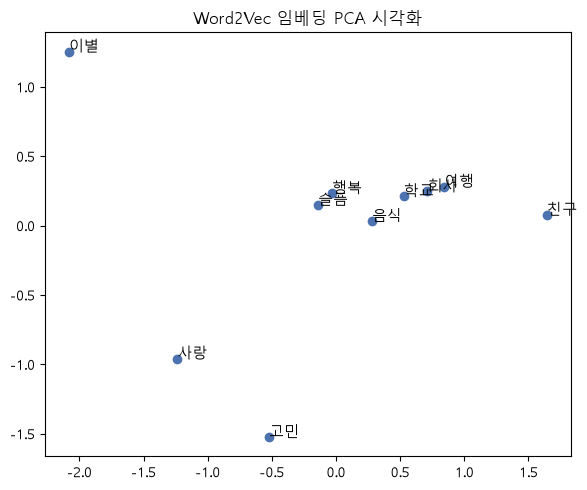

In [17]:
# 2026-09-18: 학습된 임베딩을 2차원으로 축소해 시각화 (PCA)
# PCA를 사용한 이유: t-SNE보다 계산이 훨씬 빠르고 결정론적(seed에 덜 민감)이라 간단한 정성적 확인 목적에는 충분하다.
from sklearn.decomposition import PCA

words_to_plot = ['사랑', '이별', '고민', '친구', '행복', '슬픔', '회사', '학교', '여행', '음식']
words_to_plot = [w for w in words_to_plot if w in w2v.wv]

vectors = np.array([w2v.wv[w] for w in words_to_plot])
coords = PCA(n_components=2, random_state=42).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(coords[:, 0], coords[:, 1], color='#4C72B0')
for word, (x, y) in zip(words_to_plot, coords):
    ax.annotate(word, (x, y), fontsize=11)
ax.set_title('Word2Vec 임베딩 PCA 시각화')
plt.tight_layout()
plt.savefig('../dataset/processed/word2vec_pca.png', dpi=120)
plt.show()

## 요약

| 항목 | 선택 | 핵심 근거 |
|---|---|---|
| 토큰화 단위 비교 | 어절/음절/형태소(Okt)/자모 | 형태소가 의미 단위 보존과 vocab 희소성 사이 절충점 |
| 베이스라인 토크나이저 | SentencePiece BPE (vocab 8000, 직접 학습) | OOV에 강함, 띄어쓰기에 안정적, 이후 사전학습 모델과 방식 일관성 |
| 전이학습 모델 토크나이저 | KoBART `AutoTokenizer` 그대로 사용 | 사전학습 임베딩이 그 토크나이저의 vocab index에 종속되어 있어 반드시 그대로 써야 함 |
| 단어 임베딩 | gensim Word2Vec (skip-gram, dim=100) | 저빈도 구어체 단어 표현에 유리, 소규모 코퍼스에 적정 차원 |

다음 단계(`03_baseline_transformer.ipynb`)에서는 여기서 학습한 `chatbot_bpe` 토크나이저(및 필요 시 `word2vec.model` 초기화)를 사용해 처음부터 학습하는 인코더-디코더 Transformer 베이스라인을 구현한다.